In [1]:
import math
import random
import matplotlib.pyplot as plt

In [2]:
def plot_graph(positions, edges, colors, title="Graph Coloring"):
    plt.figure(figsize=(6, 6))

    # Draw edges
    for u, v in edges:
        x = [positions[u][0], positions[v][0]]
        y = [positions[u][1], positions[v][1]]
        plt.plot(x, y, color="black", linewidth=1)

    # Draw vertices
    xs = [positions[i][0] for i in range(len(colors))]
    ys = [positions[i][1] for i in range(len(colors))]

    plt.scatter(xs, ys, c=colors, cmap="tab10", s=400)

    for i, (x, y) in enumerate(positions):
        plt.text(x, y, str(i), color="white",
                 ha="center", va="center", fontsize=12, weight="bold")

    plt.title(title)
    plt.axis("equal")
    plt.axis("off")
    plt.show()

In [3]:
class GraphColoringGA:
    def __init__(
        self,
        adjacency_matrix=None,
        edge_list=None,
        num_vertices=None,
        K_max=10,
        population_size=100,
        max_generations=200,
        pc=0.8,
        pm=0.05,
        tournament_size=3,
        elitism_count=2,
        conflict_weight=1000,
        seed=None
    ):
        if seed is not None:
            random.seed(seed)

        if adjacency_matrix is None and edge_list is None:
            raise ValueError("Provide adjacency_matrix or edge_list")

        if adjacency_matrix is not None:
            self.n = len(adjacency_matrix)
            self.edges = self._edges_from_adj_matrix(adjacency_matrix)
        else:
            self.n = num_vertices
            self.edges = edge_list

        self.K_max = K_max
        self.population_size = population_size
        self.max_generations = max_generations
        self.pc = pc
        self.pm = pm
        self.tournament_size = tournament_size
        self.elitism_count = elitism_count
        self.conflict_weight = conflict_weight

        self.fitness_history = []

        # AUTO-GENERATED POSITIONS
        self.positions = self._generate_positions()

    # Layout
    def _generate_positions(self, radius=1.5):
        """Circular layout"""
        return [
            (
                radius * math.cos(2 * math.pi * i / self.n),
                radius * math.sin(2 * math.pi * i / self.n)
            )
            for i in range(self.n)
        ]

    # GA internals
    def _edges_from_adj_matrix(self, A):
        edges = []
        for i in range(len(A)):
            for j in range(i + 1, len(A)):
                if A[i][j]:
                    edges.append((i, j))
        return edges

    def _relabel_colors(self, ind):
        mapping = {}
        next_color = 1
        new_ind = []

        for c in ind:
            if c not in mapping:
                mapping[c] = next_color
                next_color += 1
            new_ind.append(mapping[c])

        return new_ind


    def _random_individual(self):
        ind = [random.randint(1, self.K_max) for _ in range(self.n)]
        return self._relabel_colors(ind)


    def _count_conflicts(self, ind):
        return sum(1 for u, v in self.edges if ind[u] == ind[v])

    def _num_colors(self, ind):
        return len(set(ind))

    def _fitness(self, ind):
        return self._count_conflicts(ind) * self.conflict_weight + self._num_colors(ind)

    def _tournament(self, population, fitnesses):
        candidates = random.sample(range(len(population)), self.tournament_size)
        best = min(candidates, key=lambda i: fitnesses[i])
        return population[best][:]

    def _crossover(self, p1, p2):
        if random.random() > self.pc:
            return p1[:], p2[:]
        point = random.randint(1, self.n - 1)
        return (
            p1[:point] + p2[point:],
            p2[:point] + p1[point:]
        )

    def _mutation(self, ind):
        for i in range(self.n):
            if random.random() < self.pm:
                ind[i] = random.randint(1, self.K_max)
        return ind

    # GA execution
    def run(self):
        population = [self._random_individual() for _ in range(self.population_size)]

        for _ in range(self.max_generations):
            fitnesses = [self._fitness(ind) for ind in population]
            self.fitness_history.append(min(fitnesses))

            new_population = []

            elite_ids = sorted(range(len(population)), key=lambda i: fitnesses[i])[:self.elitism_count]
            for i in elite_ids:
                new_population.append(population[i][:])

            while len(new_population) < self.population_size:
                p1 = self._tournament(population, fitnesses)
                p2 = self._tournament(population, fitnesses)
                c1, c2 = self._crossover(p1, p2)
                new_population.append(self._mutation(c1))
                if len(new_population) < self.population_size:
                    new_population.append(self._mutation(c2))

            population = new_population

        fitnesses = [self._fitness(ind) for ind in population]
        best_idx = min(range(len(population)), key=lambda i: fitnesses[i])
        best = population[best_idx]

        return {
            "color_assignment": best,
            "num_colors": self._num_colors(best),
            "conflicts": self._count_conflicts(best),
            "fitness": self._fitness(best),
            "fitness_history": self.fitness_history
        }

    # Plotting helpers
    def plot_fitness(self):
        plt.figure(figsize=(8, 4))
        plt.plot(self.fitness_history)
        plt.xlabel("Generation")
        plt.ylabel("Best Fitness")
        plt.title("Fitness Convergence")
        plt.grid(True)
        plt.show()

    def plot_solution(self, colors, title="Graph Coloring"):
        plot_graph(self.positions, self.edges, colors, title)

Color assignment: [1, 2, 3, 1]
Number of colors: 3
Conflicts: 0
Final fitness: 3


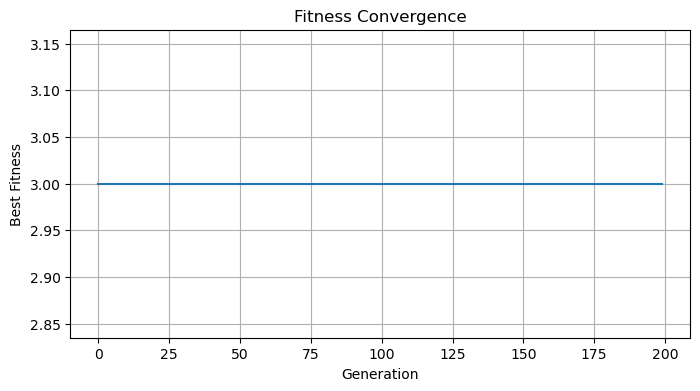

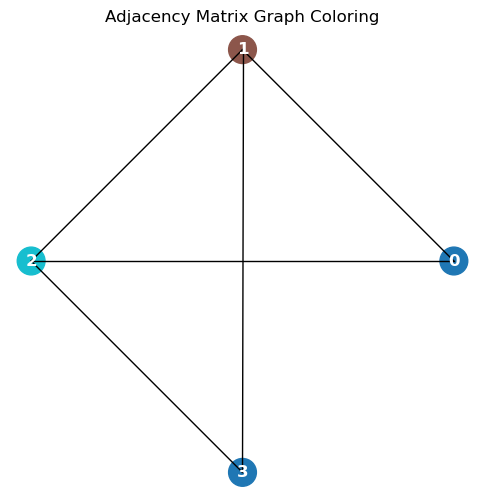

In [4]:
A = [
    [0,1,1,0,],
    [1,0,1,1],
    [1,1,0,1],
    [0,1,1,0]
]

ga = GraphColoringGA(adjacency_matrix=A, K_max=4, seed=42)

result = ga.run()

print("Color assignment:", result["color_assignment"])
print("Number of colors:", result["num_colors"])
print("Conflicts:", result["conflicts"])
print("Final fitness:", result["fitness"])

ga.plot_fitness()
ga.plot_solution(result["color_assignment"], "Adjacency Matrix Graph Coloring")

Color assignment: [1, 2, 3, 2, 3, 2, 1, 1, 3, 2]
Number of colors: 3
Conflicts: 0
Final fitness: 3


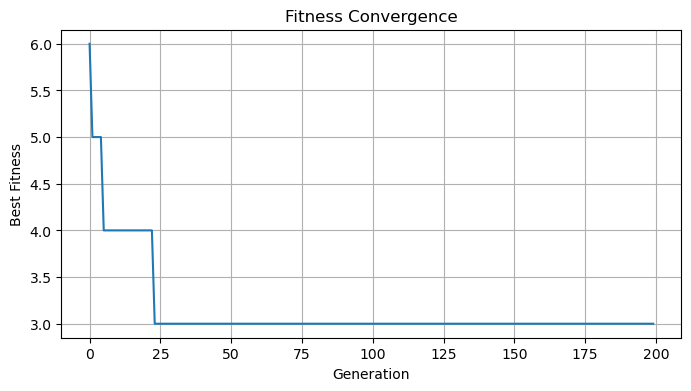

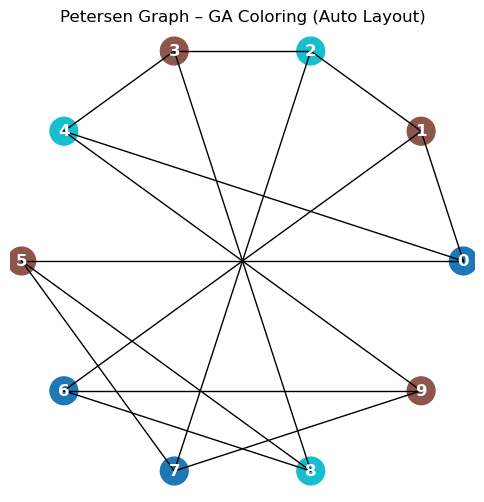

In [5]:
# Petersen graph edges
petersen_edges = [
    (0,1), (1,2), (2,3), (3,4), (4,0),
    (0,5), (1,6), (2,7), (3,8), (4,9),
    (5,7), (7,9), (9,6), (6,8), (8,5)
]

ga = GraphColoringGA(
    edge_list=petersen_edges,
    num_vertices=10,
    K_max=10,
    seed=42
)

result = ga.run()

print("Color assignment:", result["color_assignment"])
print("Number of colors:", result["num_colors"])
print("Conflicts:", result["conflicts"])
print("Final fitness:", result["fitness"])

# Fitness convergence
ga.plot_fitness()

# Graph plot using auto-generated positions
ga.plot_solution(
    result["color_assignment"],
    title="Petersen Graph – GA Coloring (Auto Layout)"
)

Color assignment: [1, 3, 2, 1, 3, 3, 1, 1, 3, 2]
Number of colors: 3
Conflicts: 0
Final fitness: 3


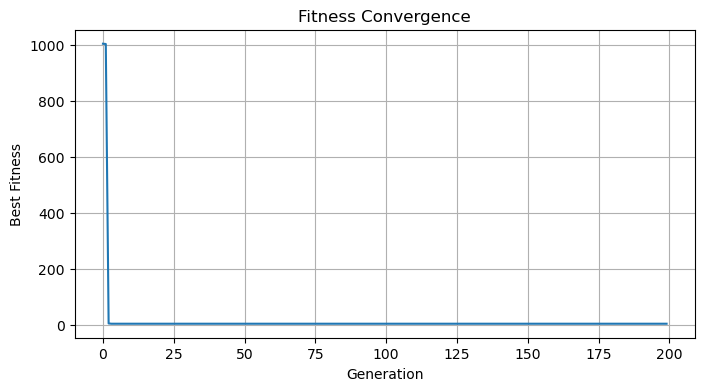

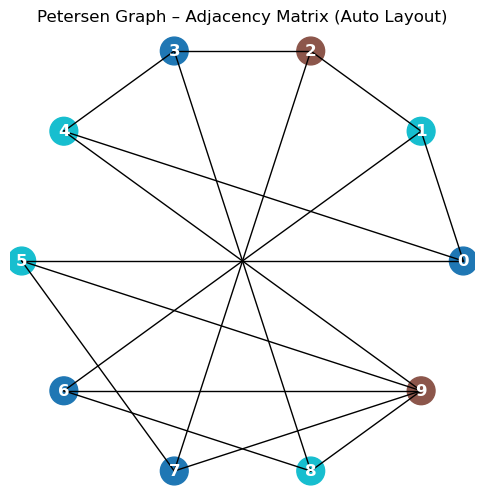

In [6]:
A_petersen = [
    # 0 1 2 3 4 5 6 7 8 9
    [0,1,0,0,1,1,0,0,0,0],  # 0
    [1,0,1,0,0,0,1,0,0,0],  # 1
    [0,1,0,1,0,0,0,1,0,0],  # 2
    [0,0,1,0,1,0,0,0,1,0],  # 3
    [1,0,0,1,0,0,0,0,0,1],  # 4
    [1,0,0,0,0,0,0,1,0,1],  # 5
    [0,1,0,0,0,0,0,0,1,1],  # 6
    [0,0,1,0,0,1,0,0,0,1],  # 7
    [0,0,0,1,0,0,1,0,0,1],  # 8
    [0,0,0,0,1,1,1,1,1,0],  # 9
]

ga = GraphColoringGA(
    adjacency_matrix=A_petersen,
    K_max=4,          
    seed=42
)

result = ga.run()

print("Color assignment:", result["color_assignment"])
print("Number of colors:", result["num_colors"])
print("Conflicts:", result["conflicts"])
print("Final fitness:", result["fitness"])

ga.plot_fitness()
ga.plot_solution(result["color_assignment"],
                 title="Petersen Graph – Adjacency Matrix (Auto Layout)")

In [7]:
def read_adjacency_matrix():
    n = int(input("Enter number of vertices: "))

    print("Enter adjacency matrix row by row (space separated):")

    A = []
    for i in range(n):
        row = list(map(int, input(f"Row {i}: ").split()))

        if len(row) != n:
            raise ValueError("Each row must have exactly n numbers.")

        A.append(row)

    # validation
    for i in range(n):
        if A[i][i] != 0:
            raise ValueError("Diagonal elements must be zero.")

        for j in range(n):
            if A[i][j] not in (0, 1):
                raise ValueError("Matrix must contain only 0 or 1.")
            if A[i][j] != A[j][i]:
                raise ValueError("Matrix must be symmetric.")

    return A

Now, by running the next cell, you can give the number of vertices and your adjacency matrix row by row. You can adjust `K_max`, which is the maximum allowed colors.

Enter adjacency matrix row by row (space separated):
Color assignment: [1, 2, 3, 1, 2, 3]
Number of colors: 3
Conflicts: 0
Final fitness: 3


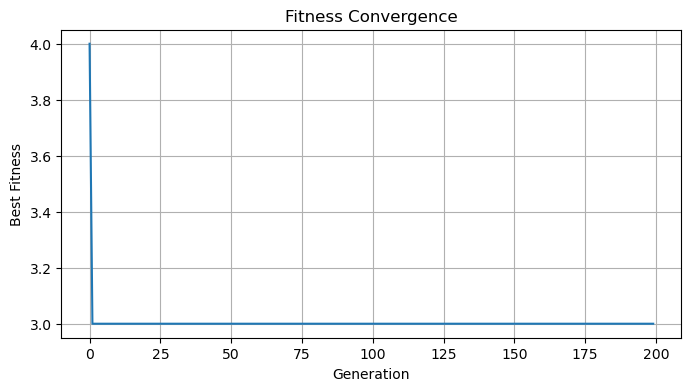

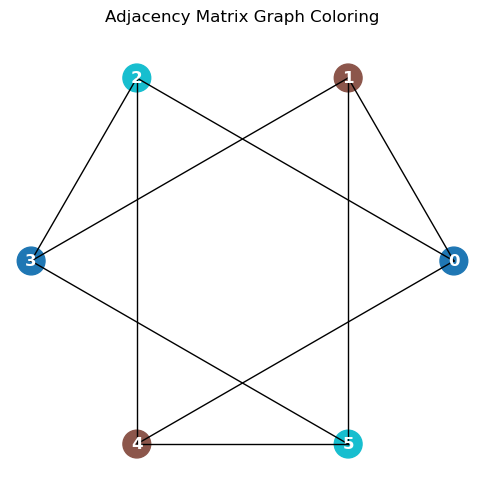

In [9]:
A = read_adjacency_matrix()

ga = GraphColoringGA(adjacency_matrix=A, K_max=4, seed=42)

result = ga.run()

print("Color assignment:", result["color_assignment"])
print("Number of colors:", result["num_colors"])
print("Conflicts:", result["conflicts"])
print("Final fitness:", result["fitness"])

ga.plot_fitness()
ga.plot_solution(result["color_assignment"], "Adjacency Matrix Graph Coloring")